# NLP Customer Feedback Analysis

A compact pipeline: preprocessing, features, sentiment, intent, topics, evaluation and Gradio demo.

In [58]:
# Imports
import os
import re, string
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
from sklearn.decomposition import NMF
from sklearn.preprocessing import LabelEncoder
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import SnowballStemmer
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import unidecode
import gradio as gr
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
# Ensure results folders exist
os.makedirs('results/plots', exist_ok=True)
os.makedirs('results/models', exist_ok=True)
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('vader_lexicon')
# Reproducible random seed
RND = 42

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\pc\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\pc\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\pc\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


## Load Data

In [59]:
# Load the provided dataset (uses 'Review' column)
df = pd.read_csv(r"C:\\Users\\pc\\Desktop\\MISC\\NLP\\data\\flipkart_product.csv", encoding="latin1")
df = df[['Review','Summary','Rate']].rename(columns={'Review':'review','Summary':'summary','Rate':'rating'})
df = df.dropna(subset=['review']).reset_index(drop=True)
df.head(5)

,review,summary,rating
0,Super!,Great cooler.. excellent air flow and for this...,5
1,Awesome,Best budget 2 fit cooler. Nice cooling,5
2,Fair,The quality is good but the power of air is de...,3
3,Useless product,Very bad product it's a only a fan,1
4,Fair,Ok ok product,3


## Preprocessing

In [60]:
# Add configurable number of noisy reviews (Roman-Urdu, short complaints)
# Set `NOISY_N` to desired number of synthetic/noisy samples to append
NOISY_N = 20000
base_noisy = [
    ('product bohut kharab hai, paise wapis chahiye', 1),
    ('Not working since day1. refund pls!', 1),
    ('delivery late, order ni mila', 1),
    ('acha product, but package damage hua', 3),
    ('plz return, item broken', 1),
    ('awesome!!! 10/10 loved it', 5),
    ('ye product bilkul bekaar hai', 1),
    ('cannot use, screen broken :(', 1),
    ('arrived late, delivery boy rude', 2),
    ('refund asap, item wasted', 1),
    ('bahut acha product, recommend', 5),
    ('box open milaa, kuch missing', 1),
    ('charger missing, please send', 1),
    ('slow charging, not good', 2),
    ('sound is poor, disappointed', 1),
    ('delivery boy not cooperative', 2),
    ('item received damaged and scratched', 1),
    ('quality exceeded expectation', 5),
    ('battery backup is amazing', 5),
    ('fake product delivered', 1),
    ('wrong color delivered', 2),
    ('installation support was helpful', 4),
    ('app not connecting to device', 2),
    ('warranty claim rejected unfairly', 1),
    ('refund processed quickly, thanks', 5)
]
# create NOISY_N samples by sampling with replacement and applying light perturbations
import random
noisy_rows = []
for i in range(NOISY_N):
    t, r = random.choice(base_noisy)
    # small perturbations: lowercase/uppercase mix, add short typos, or shorten
    if random.random() < 0.12:
        t = t.replace('product', 'prd').replace('delivery', 'deliv')
    if random.random() < 0.08:
        t = t + ' pls'
    if random.random() < 0.05:
        t = t.replace(' ', '')[:30]
    noisy_rows.append({'review': t, 'summary': 'noisy', 'rating': r})
noisy = pd.DataFrame(noisy_rows)
df = pd.concat([df, noisy], ignore_index=True)
df = df.reset_index(drop=True)
print(f'Added {len(noisy)} noisy reviews; dataset size now {len(df)}')

Added 20000 noisy reviews; dataset size now 209870


In [61]:
# Preprocessing utilities (improved Roman Urdu handling)
stemmer = SnowballStemmer('english')
en_stop = set(stopwords.words('english'))
# Expand Roman-Urdu mapping and stopwords
roman_to_en = {
    'acha':'good','achha':'good','achaa':'good',
    'nahi':'no','nahin':'no','nah':'no','nhi':'no',
    'bhai':'bro','shukriya':'thanks','shukria':'thanks',
    'plz':'please','pls':'please','thx':'thanks','tnx':'thanks',
    'masla':'issue','kaam':'work','kam':'less','zabardast':'great',
    'kharab':'bad','kharaab':'bad','yaar':'mate','sahi':'right',
    'refund':'refund','return':'refund'
}
roman_stop = set(list(roman_to_en.keys()) + ['hai','haiy','ye','wo','the'])
sia = SentimentIntensityAnalyzer()
def normalize_repeated_chars(text):
    return re.sub(r'(\w)\1{2,}', r'\1\1', text)
def expand_roman_tokens(text):
    # replace common roman-urdu tokens with English equivalents to aid English stemmer/tokenizer
    toks = text.split()
    out = []
    for t in toks:
        t_clean = re.sub(r'[^a-z0-9]', '', t)
        if t_clean in roman_to_en:
            out.append(roman_to_en[t_clean])
        else:
            out.append(t)
    return ' '.join(out)
def preprocess_text(text):
    if not isinstance(text, str):
        return ''
    text = unidecode.unidecode(text)
    text = text.lower()
    # normalize emoticons / common short forms
    text = re.sub(r'(:\)|:\(|;\))', ' ', text)
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'\S+@\S+', ' ', text)
    # expand roman-urdu tokens early
    text = expand_roman_tokens(text)
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\d+', ' ', text)
    text = normalize_repeated_chars(text)
    # Use a simple regex tokenizer to avoid NLTK punkt dependency
    toks = re.findall(r'\b[a-z0-9]+\b', text)
    toks = [t for t in toks if t not in en_stop and t not in roman_stop and len(t)>1]
    toks = [stemmer.stem(t) for t in toks]
    return ' '.join(toks)
# Show examples before/after
samples = df['review'].sample(8, random_state=RND).tolist()
pairs = [(s, preprocess_text(s)) for s in samples]
pairs

[('Must buy!', 'must buy'),
 ('Nan', 'nan'),
 ('Highly recommended', 'high recommend'),
 ('battery backup is amazing', 'batteri backup amaz'),
 ('Nan', 'nan'),
 ('Value-for-money', 'valu money'),
 ('Worth every penny', 'worth everi penni'),
 ('Just okay', 'okay')]

## Feature Extraction

In [62]:
# Prepare labels for sentiment from rating: 4-5=positive,3=neutral,1-2=negative
def map_rating(r):
    try:
        r = float(r)
    except:
        return 'neutral'
    if r >= 4: return 'positive'
    if r == 3: return 'neutral'
    return 'negative'
df['sentiment'] = df['rating'].apply(map_rating)
# Sample subset to speed experiments
SAMPLE_N = min(len(df), 10000)
df_small = df.sample(SAMPLE_N, random_state=RND).reset_index(drop=True)
df_small['text'] = df_small['review'].apply(preprocess_text)
# Vectorizers
cv = CountVectorizer(max_features=5000, ngram_range=(1,2))
tv = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_bow = cv.fit_transform(df_small['text'])
X_tfidf = tv.fit_transform(df_small['text'])
y_sent = df_small['sentiment']
print('Shapes:', X_bow.shape, X_tfidf.shape, y_sent.shape)

Shapes: (10000, 488) (10000, 488) (10000,)


## Rule-based Sentiment (VADER)

In [63]:
# VADER on original (not stemmed) text to preserve emotive words
df_small['vader_compound'] = df_small['review'].apply(lambda t: sia.polarity_scores(str(t))['compound'])
def vader_label(c):
    if c >= 0.05: return 'positive'
    if c <= -0.05: return 'negative'
    return 'neutral'
df_small['vader_sent'] = df_small['vader_compound'].apply(vader_label)
print(classification_report(df_small['sentiment'], df_small['vader_sent'], zero_division=0))

              precision    recall  f1-score   support

    negative       0.96      0.58      0.72      1798
     neutral       0.13      0.38      0.20       817
    positive       0.90      0.80      0.85      7385

    accuracy                           0.73     10000
   macro avg       0.66      0.59      0.59     10000
weighted avg       0.85      0.73      0.77     10000



## ML Sentiment (Logistic Regression)

In [64]:
# Compare BoW vs TF-IDF with Logistic Regression
le = LabelEncoder()
y_enc = le.fit_transform(y_sent)
Xb_train, Xb_test, yb_train, yb_test = train_test_split(X_bow, y_enc, test_size=0.2, random_state=RND, stratify=y_enc)
Xt_train, Xt_test, yt_train, yt_test = train_test_split(X_tfidf, y_enc, test_size=0.2, random_state=RND, stratify=y_enc)
clf_bow = LogisticRegression(max_iter=1000, random_state=RND)
clf_tfidf = LogisticRegression(max_iter=1000, random_state=RND)
clf_bow.fit(Xb_train, yb_train)
clf_tfidf.fit(Xt_train, yt_train)
pred_bow = clf_bow.predict(Xb_test)
pred_tfidf = clf_tfidf.predict(Xt_test)
print('BoW Results:\n', classification_report(yb_test, pred_bow, target_names=le.classes_, zero_division=0))
print('TF-IDF Results:\n', classification_report(yt_test, pred_tfidf, target_names=le.classes_, zero_division=0))
# Save TF-IDF pipeline objects for interface (saved under results/models)
joblib.dump(tv, 'results/models/tfidf_vectorizer.joblib')
joblib.dump(clf_tfidf, 'results/models/sentiment_clf_lr.joblib')
joblib.dump(le, 'results/models/sentiment_label_encoder.joblib')

BoW Results:
               precision    recall  f1-score   support

    negative       1.00      0.88      0.93       360
     neutral       0.98      0.70      0.82       163
    positive       0.94      1.00      0.97      1477

    accuracy                           0.95      2000
   macro avg       0.97      0.86      0.91      2000
weighted avg       0.95      0.95      0.95      2000

TF-IDF Results:
               precision    recall  f1-score   support

    negative       1.00      0.88      0.93       360
     neutral       0.98      0.70      0.82       163
    positive       0.94      1.00      0.97      1477

    accuracy                           0.95      2000
   macro avg       0.97      0.86      0.91      2000
weighted avg       0.95      0.95      0.95      2000



['results/models/sentiment_label_encoder.joblib']

## Intent Classification

In [65]:
# Heuristic labeling to get quick intent labels (supervised training)
def heuristic_intent(text):
    t = str(text).lower()
    if any(k in t for k in ['refund','return','money back','replace','exchange']):
        return 'Refund Request'
    if any(k in t for k in ['deliver','delivery','late','not delivered','tracking','shipped']):
        return 'Delivery Issue'
    if any(k in t for k in ['broken','defect','damage','waste','not work','useless','bad']):
        return 'Complaint'
    return 'General Query'
df_small['intent'] = df_small['review'].apply(heuristic_intent)
# Vectorize and train
intent_tv = TfidfVectorizer(max_features=3000, ngram_range=(1,2))
X_int = intent_tv.fit_transform(df_small['text'])
le_int = LabelEncoder()
y_int = le_int.fit_transform(df_small['intent'])
Xi_train, Xi_test, yi_train, yi_test = train_test_split(X_int, y_int, test_size=0.2, random_state=RND, stratify=y_int)
intent_clf = LogisticRegression(max_iter=1000, random_state=RND)
intent_clf.fit(Xi_train, yi_train)
pred_int = intent_clf.predict(Xi_test)
# Ensure classification_report's target_names match the classes present in the test/pred arrays
present = np.unique(np.concatenate([yi_test, pred_int]))
present_names = [le_int.classes_[i] for i in present]
print(classification_report(yi_test, pred_int, labels=present, target_names=present_names, zero_division=0))
# Save intent artifacts
joblib.dump(intent_tv, 'results/models/intent_tfidf.joblib')
joblib.dump(intent_clf, 'results/models/intent_clf.joblib')
joblib.dump(le_int, 'results/models/intent_label_encoder.joblib')

                precision    recall  f1-score   support

     Complaint       1.00      0.98      0.99        66
Delivery Issue       1.00      1.00      1.00        32
 General Query       1.00      1.00      1.00      1872
Refund Request       1.00      1.00      1.00        30

      accuracy                           1.00      2000
     macro avg       1.00      1.00      1.00      2000
  weighted avg       1.00      1.00      1.00      2000



['results/models/intent_label_encoder.joblib']

## Topic Modeling (NMF)

In [66]:
# Use TF-IDF and NMF to extract topics
topic_tv = TfidfVectorizer(max_features=2000, ngram_range=(1,2), stop_words='english')
X_topic = topic_tv.fit_transform(df_small['review'].astype(str))
n_topics = 6
nmf = NMF(n_components=n_topics, random_state=RND, init='nndsvda', max_iter=200)
W = nmf.fit_transform(X_topic)
H = nmf.components_
vocab = np.array(topic_tv.get_feature_names_out())
def show_topics(H, vocab, topn=8):
    topics = []
    for comp in H:
        terms = vocab[np.argsort(comp)[-topn:]][::-1]
        topics.append(' '.join(terms))
    return topics
topics = show_topics(H, vocab)
for i,t in enumerate(topics): print(f'Topic {i+1}:', t)
# Save topic model and vectorizer
joblib.dump(topic_tv, 'results/models/topic_tfidf.joblib')
joblib.dump(nmf, 'results/models/nmf_model.joblib')
# Create a simple visualization of topics and save to results/topics.png
plt.figure(figsize=(8, 6))
plt.axis('off')
txt = '\n'.join([f'Topic {i+1}: {t}' for i,t in enumerate(topics)])
plt.text(0, 1, txt, fontsize=10, va='top')
plt.tight_layout()
plt.savefig('results/topics.png', dpi=200, bbox_inches='tight')
plt.close()

Topic 1: nan worth penny worth penny money worth money value money value
Topic 2: good choice good choice pretty good pretty good quality quality product quality
Topic 3: terrific purchase terrific purchase blowing mind mind blowing blowing purchase good experience
Topic 4: wonderful worth penny worth penny money worth money recommended highly
Topic 5: awesome simply awesome simply 10 awesome 10 loved 10 10 10 loved
Topic 6: product classy product classy nice perfect product perfect great product great


## Evaluation Summary

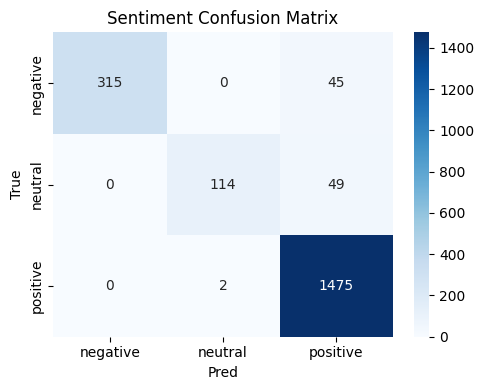

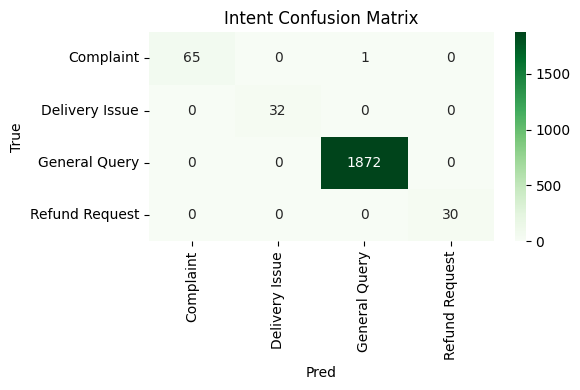

C:\Users\pc\AppData\Local\Temp\ipykernel_7636\3605818900.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dist.index, y=dist.values, palette='muted')


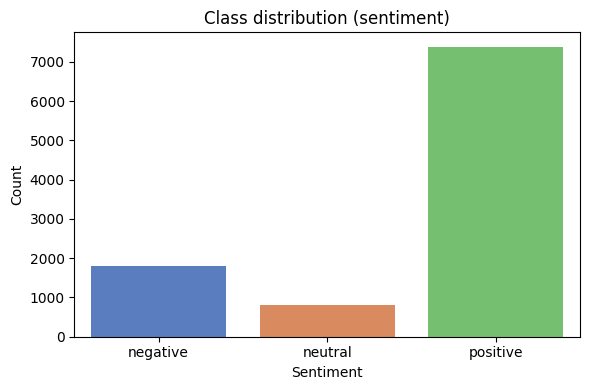

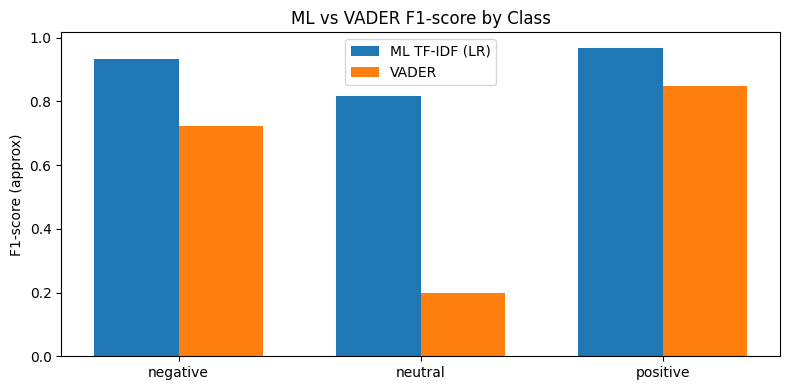

Most suitable metric: F1-score (balances precision and recall).


In [67]:
# Confusion matrix examples for sentiment (TF-IDF) and intent
import matplotlib.pyplot as plt
import seaborn as sns
# Sentiment (save plot to results/plots)
cm_sent = confusion_matrix(yt_test, pred_tfidf)
plt.figure(figsize=(5,4))
sns.heatmap(cm_sent, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.title('Sentiment Confusion Matrix')
plt.xlabel('Pred')
plt.ylabel('True')
plt.tight_layout()
plt.savefig('results/plots/sent_confusion.png', dpi=200)
plt.show()
# Intent (save plot to results/plots)
cm_int = confusion_matrix(yi_test, pred_int)
plt.figure(figsize=(6,4))
sns.heatmap(cm_int, annot=True, fmt='d', xticklabels=le_int.classes_, yticklabels=le_int.classes_, cmap='Greens')
plt.title('Intent Confusion Matrix')
plt.xlabel('Pred')
plt.ylabel('True')
plt.tight_layout()
plt.savefig('results/plots/intent_confusion.png', dpi=200)
plt.show()
# --- Additional plots: class distribution and VADER vs ML comparison
# class distribution (true labels in the sampled dataset)
plt.figure(figsize=(6,4))
dist = pd.Series(y_sent).value_counts().reindex(le.classes_)
sns.barplot(x=dist.index, y=dist.values, palette='muted')
plt.title('Class distribution (sentiment)')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('results/plots/class_distribution.png', dpi=200)
plt.show()
# Compare VADER (rule-based) vs ML (TF-IDF LR) F1-scores per class
from sklearn.metrics import f1_score
# Prepare ML predictions aligned to labels
ml_pred_labels = le.inverse_transform(pred_tfidf)
vader_labels = df_small['vader_sent'].loc[yt_test.index] if hasattr(yt_test, 'index') else df_small['vader_sent']
# compute F1 per class where possible
ml_f1 = []
vader_f1 = []
for cls in le.classes_:
    try:
        ml_f1.append(f1_score(yt_test, pred_tfidf, labels=[list(le.classes_).index(cls)], average='macro'))
    except Exception:
        ml_f1.append(0.0)
    try:
        # map vader string labels to same order
        vader_true = df_small['sentiment']
        vader_pred = df_small['vader_sent']
        vader_f1.append(f1_score(vader_true, vader_pred, labels=[cls], average='macro'))
    except Exception:
        vader_f1.append(0.0)
# Plot comparison
x = np.arange(len(le.classes_))
width = 0.35
plt.figure(figsize=(8,4))
plt.bar(x - width/2, ml_f1, width, label='ML TF-IDF (LR)')
plt.bar(x + width/2, vader_f1, width, label='VADER')
plt.xticks(x, le.classes_)
plt.ylabel('F1-score (approx)')
plt.title('ML vs VADER F1-score by Class')
plt.legend()
plt.tight_layout()
plt.savefig('results/plots/sentiment_compare.png', dpi=200)
plt.show()
# Note: F1-score balances precision & recall; useful when classes imbalanced
print('Most suitable metric: F1-score (balances precision and recall).')

## Gradio Interface

In [68]:
# Load saved artifacts (from results/models)
tv = joblib.load('results/models/tfidf_vectorizer.joblib')
sent_clf = joblib.load('results/models/sentiment_clf_lr.joblib')
sent_le = joblib.load('results/models/sentiment_label_encoder.joblib')
intent_tv = joblib.load('results/models/intent_tfidf.joblib')
intent_clf = joblib.load('results/models/intent_clf.joblib')
intent_le = joblib.load('results/models/intent_label_encoder.joblib')
topic_tv = joblib.load('results/models/topic_tfidf.joblib')
nmf = joblib.load('results/models/nmf_model.joblib')
# Helper to get top keywords from TF-IDF for a single input (use preprocessed text)
def top_keywords(preprocessed_text, tv, topn=6):
    X = tv.transform([preprocessed_text])
    arr = X.toarray()[0]
    if arr.sum() == 0:
        return ''
    idx = np.argsort(arr)[-topn:][::-1]
    feat = np.array(tv.get_feature_names_out())
    return ', '.join(feat[idx])
def predict(review):
    pre = preprocess_text(review)
    if not pre: pre = review.lower()
    X = tv.transform([pre])
    # Sentiment probabilities (map class->prob)
    if hasattr(sent_clf, 'predict_proba'):
        probs = sent_clf.predict_proba(X)[0]
        classes = list(sent_le.classes_)
        sent_dict = {c: float(p) for c,p in zip(classes, probs)}
    else:
        pred_idx = sent_clf.predict(X)[0]
        sent_label = sent_le.inverse_transform([pred_idx])[0]
        sent_dict = {sent_label: 1.0}
    # Intent probabilities
    if hasattr(intent_clf, 'predict_proba'):
        ip = intent_clf.predict_proba(intent_tv.transform([pre]))[0]
        iclasses = list(intent_le.classes_)
        intent_dict = {c: float(p) for c,p in zip(iclasses, ip)}
    else:
        idx = intent_clf.predict(intent_tv.transform([pre]))[0]
        intent_dict = {intent_le.inverse_transform([idx])[0]: 1.0}
    keywords = top_keywords(pre, topic_tv, topn=6)
    return sent_dict, intent_dict, f'Top keywords: {keywords}'
demo = gr.Interface(fn=predict, inputs=gr.Textbox(lines=3, placeholder='Enter customer review...'), outputs=[gr.Label(num_top_classes=3), gr.Label(num_top_classes=1), gr.Textbox()], title='Feedback Analyzer')
# To run the demo in the notebook, call demo.launch() (uncomment below to start)
demo.launch(share=False)

* Running on local URL:  http://127.0.0.1:7862
* To create a public link, set `share=True` in `launch()`.
